# M/M/... Queues

This notebook showcases six classic queueing models, all built on the birth-death process. They are named in **Kendall's notation** `M/M/s/K/N`: Markovian (Poisson) arrivals, Markovian (Exponential) service, `s` servers, capacity `K`, and calling population `N`. In every model the state is the number of customers in the system, and each draw is a sample path -- the number in the system as a function of continuous time.

| Class | Model | Servers | Capacity | Population |
|---|---|---|---|---|
| `MM1` | single server | 1 | unlimited | unlimited |
| `MMs` | multi-server | s | unlimited | unlimited |
| `MMsK` | finite capacity | s | K | unlimited |
| `MMss` | Erlang loss (no waiting) | s | s | unlimited |
| `MMsKN` | machine repair | s | K | N |
| `MMInfinity` | infinite servers | infinity | unlimited | unlimited |

The unbounded models (`MM1`, `MMs`, `MMInfinity`) take a `num_states` truncation for simulation; the finite ones are exact.

In [32]:
from symbulate import *
from math import factorial, exp

## M/M/1 -- single server

The canonical queue: one server, unlimited waiting room. Stable when `arrival_rate < service_rate`.

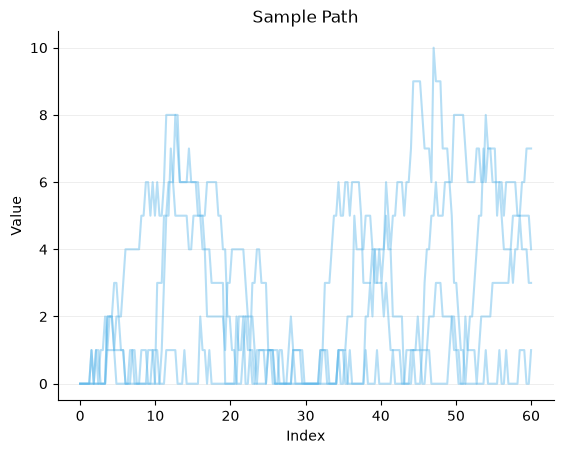

In [33]:
mm1 = MM1(arrival_rate=1, service_rate=1.5)
mm1.sim(4).plot(tmin=0, tmax=60)

## M/M/s -- multiple servers

With `s` servers, up to `s` customers are served at once, so the service rate is state-dependent: `min(n, s) * service_rate`. Stable when `arrival_rate < s * service_rate`.

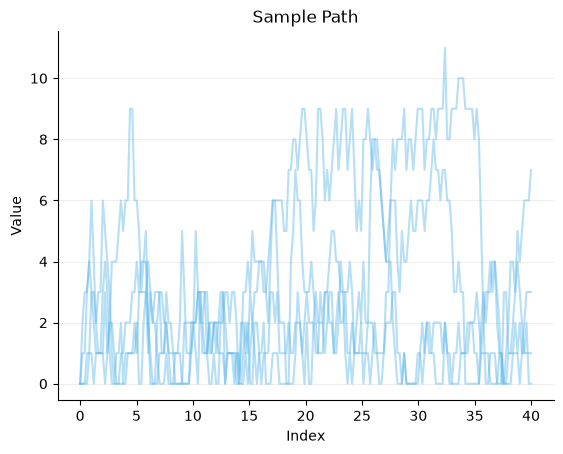

In [34]:
mms = MMs(arrival_rate=3, service_rate=2, servers=2)
mms.sim(4).plot(tmin=0, tmax=40)

## M/M/s/K -- finite capacity

The system holds at most `capacity` customers; an arrival to a full system is turned away. Because the state space is finite (`0, ..., K`), this is an **exact** chain -- not a truncation.

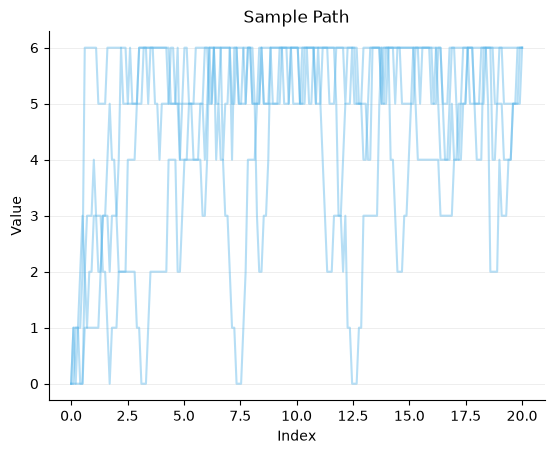

In [35]:
mmsk = MMsK(arrival_rate=4, service_rate=1, servers=2, capacity=6)
mmsk.sim(4).plot(tmin=0, tmax=20)

## M/M/s/s -- Erlang loss system

The special case with **no waiting room** (`capacity = servers`): a customer who arrives while all servers are busy is lost. The long-run fraction lost is the **Erlang B** formula.

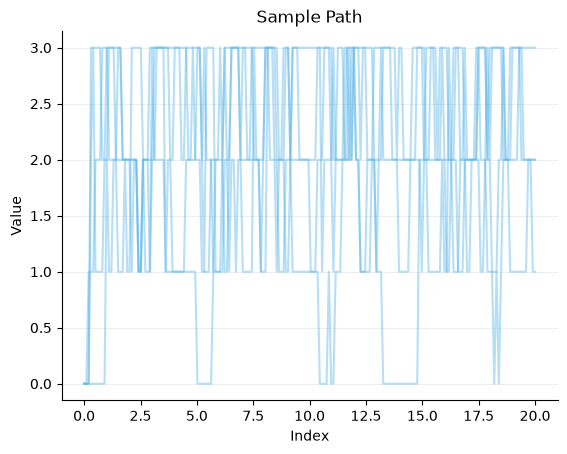

In [36]:
loss = MMss(arrival_rate=3, service_rate=1, servers=3)
loss.sim(4).plot(tmin=0, tmax=20)

## M/M/s/K/N -- machine repair (finite population)

A finite population of `N` machines, each of which breaks down at rate `arrival_rate`, and `s` repair technicians. The state is the number of broken machines, and the **arrival (breakdown) rate is state-dependent**: with `n` already broken, only `N - n` machines are still running, so breakdowns happen at rate `(N - n) * arrival_rate` -- it slows as more break.

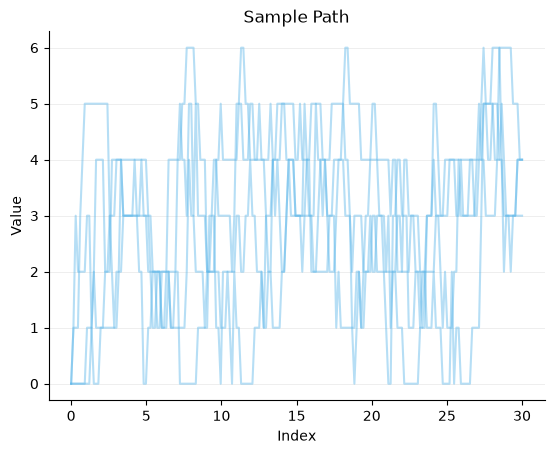

In [37]:
repair = MMsKN(arrival_rate=0.5, service_rate=1, servers=2, capacity=6, population=6)
repair.sim(4).plot(tmin=0, tmax=30)

In [38]:
# Average number of broken machines in the long run.
broken = [repair.draw()(30) for _ in range(1500)]
print(f"average number broken: {sum(broken) / len(broken):.2f} out of 6")

average number broken: 2.62 out of 6


## M/M/infinity -- infinite servers

Every customer is served immediately (there is always a free server), so the service rate is `n * service_rate` with `n` in the system.

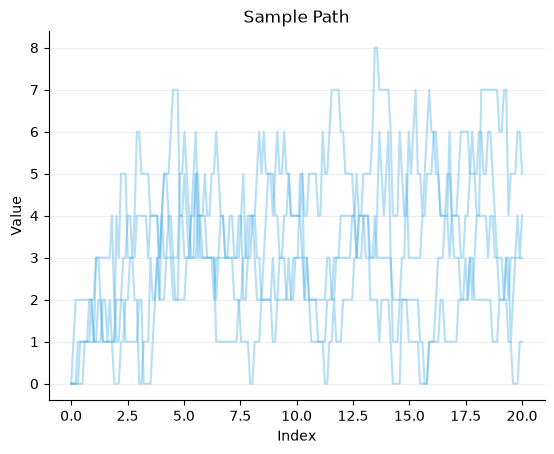

In [39]:
inf_queue = MMInfinity(arrival_rate=3, service_rate=1, num_states=20)
inf_queue.sim(4).plot(tmin=0, tmax=20)